In [1]:
from pathlib import Path

MODEL='Version3'

DATASET_PATH=Path('preprocessed_data')

DATASET_PATH.mkdir(parents=True, exist_ok=True)

EVALUATE = True

DATASETS_TO_EXCLUDE = ['tr'] #Datasets to exclude from evaluation

DATASET_TO_CHECK = ['kanjivg'] #Datasets to show images and example predictions from

In [2]:
import json
def get_word_files(dataset_path, isTr=False):
    with open(str(dataset_path / 'labels.json'), 'r') as fp:
        data_dict = json.load(fp)

    if isTr:
        words_files = list(data_dict['labels'].items())
    else:
        words_files = list(data_dict.items())
    print(words_files[0])
    print(f"{len(words_files)} words")
    return(data_dict)

In [3]:
kmnist_dict = get_word_files(DATASET_PATH / 'kmnist')
k49_dict = get_word_files(DATASET_PATH / 'K49')
kanjivg_dict = get_word_files(DATASET_PATH / 'kanjivg')
kkanji2_dict = get_word_files(DATASET_PATH / 'kkanji2')
tr_dict = get_word_files(DATASET_PATH / 'text_renderer', isTr=True)

kmnist_words = list(kmnist_dict.items())
k49_words = list(k49_dict.items())
kanjivg_words = list(kanjivg_dict.items())
kkanji2_words = list(kkanji2_dict.items())
tr_words = list(tr_dict['labels'].items())

words_list = [(kmnist_words, 'kmnist'), (k49_words, 'k49'), (kanjivg_words, 'kanjivg'), (kkanji2_words, 'kkanji2'), (tr_words, 'tr'),]

('preprocessed_data/kmnist/0.png', 'す')
240000 words
('preprocessed_data/K49/0.png', 'と')
929460 words
('preprocessed_data/kanjivg/凶.png', '凶')
14624 words
('preprocessed_data/kkanji2/0038a0f9c5d87bbe.png.png', '一')
1483999 words
('000000000', 'た。')
2000000 words


In [4]:
from typing import Tuple
import tqdm
import torch
from dtrocr.config import DTrOCRConfig
from torch.utils.data import DataLoader
import torch
torch.set_float32_matmul_precision('high')
from dtrocr.model import DTrOCRLMHeadModel

def evaluate_model(model: torch.nn.Module, dataloader: DataLoader) -> Tuple[float, float]:
    # set model to evaluation mode
    model.eval()
    
    losses, accuracies = [], []
    with torch.no_grad():
        for inputs in tqdm.tqdm(dataloader, total=len(dataloader), desc=f'Evaluating test set'):
            inputs = send_inputs_to_device(inputs, device=0)
            outputs = model(**inputs)
            
            losses.append(outputs.loss.item())
            accuracies.append(outputs.accuracy.item())
    
    loss = sum(losses) / len(losses)
    accuracy = sum(accuracies) / len(accuracies)
    
    # set model back to training mode
    model.train()
    
    return loss, accuracy

def send_inputs_to_device(dictionary, device):
    return {key: value.to(device=device) if isinstance(value, torch.Tensor) else value for key, value in dictionary.items()}



model = DTrOCRLMHeadModel(DTrOCRConfig())
model = torch.compile(model)
model.load_state_dict(torch.load(f'../models/{MODEL}.pt'))
model.to(device=0)



/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OptimizedModule(
  (_orig_mod): DTrOCRLMHeadModel(
    (transformer): DTrOCRModel(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(4, 8), stride=(4, 8))
      )
      (token_embedding): Embedding(32000, 768)
      (positional_embedding): Embedding(256, 768)
      (hidden_layers): ModuleList(
        (0-11): 12 x GPT2Block(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): GPT2SdpaAttention(
            (c_attn): Conv1D()
            (c_proj): Conv1D()
            (attn_dropout): Dropout(p=0.1, inplace=False)
            (resid_dropout): Dropout(p=0.1, inplace=False)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): GPT2MLP(
            (c_fc): Conv1D()
            (c_proj): Conv1D()
            (act): NewGELUActivation()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)


In [5]:
from dtrocr.processor import DTrOCRProcessor
from dtrocr.config import DTrOCRConfig
from pathlib import Path
from dataclasses import dataclass
from PIL import Image
from torch.utils.data import Dataset
  
@dataclass
class Word:
    file_path: Path
    transcription: str
    

def get_word(word_file):
    words = []
    words.append(
        Word(
            file_path=word_file[0],
            transcription=word_file[1]
        )
    )
    return words

def get_tr_word(word_file):
    words = []
    file_path = str(DATASET_PATH / 'text_renderer' / 'images' / (word_file[0] + '.jpg'))
    words.append(
        Word(
            file_path=file_path,
            transcription=word_file[1]
        )
    )
    return words
    
class IAMDataset(Dataset):
    def __init__(self, words: list[Word], config: DTrOCRConfig):
        super(IAMDataset, self).__init__()
        self.words = words
        self.processor = DTrOCRProcessor(config, add_eos_token=True, add_bos_token=True)
        
    def __len__(self):
        return len(self.words)
    
    def __getitem__(self, item):
        inputs = self.processor(
            images=Image.open(self.words[item].file_path).convert('RGB'),
            texts=self.words[item].transcription,
            padding='max_length',
            return_tensors="pt",
            return_labels=True,
        )
        return {
            'pixel_values': inputs.pixel_values[0],
            'input_ids': inputs.input_ids[0],
            'input_attention_mask': inputs.input_attention_mask[0],
            'label_attention_mask': inputs.label_attention_mask[0],
            'labels': inputs.labels[0]
        }

config = DTrOCRConfig(
    # attn_implementation='flash_attention_2'
)




In [6]:
import tqdm
import multiprocessing as mp

train_word_records = {}
for pair in words_list:
    isTr = pair[1] == 'tr'
    if pair[1] in DATASETS_TO_EXCLUDE : continue
    with mp.Pool(processes=mp.cpu_count()) as pool:
        word_list = list(
            tqdm.tqdm(
                pool.imap(get_tr_word, pair[0]) if isTr else pool.imap(get_word, pair[0]), 
                total=len(pair[0]),
                desc='Building dataset'
            )
        )
    words = [word for words_array in word_list for word in words_array]
    train_word_records[pair[1]] = words
    print(words[0])
    if EVALUATE:
        data = IAMDataset(words=words, config=config)
        dataloader = DataLoader(data, batch_size=32, shuffle=True, num_workers=mp.cpu_count())
        loss, accuracy = evaluate_model(model, dataloader)
            
        print(f"{pair[1]} loss: {loss}, accuracy: {accuracy}")

Building dataset: 100%|██████████| 240000/240000 [00:48<00:00, 4900.24it/s] 


Word(file_path='preprocessed_data/kmnist/0.png', transcription='す')


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Evaluating test set: 100%|██████████| 7500/7500 [30:18<00:00,  4.13it/s]

kmnist loss: 3.8641748308499655, accuracy: 0.5687709200660388



Building dataset: 100%|██████████| 929460/929460 [03:14<00:00, 4776.97it/s] 


...

kanjivg loss: 4.639039056828038, accuracy: 0.4353851657727615



Building dataset: 100%|██████████| 1483999/1483999 [04:53<00:00, 5062.50it/s] 


Word(file_path='preprocessed_data/kkanji2/0038a0f9c5d87bbe.png.png', transcription='一')


Evaluating test set: 100%|██████████| 46375/46375 [3:09:33<00:00,  4.08it/s]  

kkanji2 loss: 4.936624079485788, accuracy: 0.4812644030443742


In [7]:
from dtrocr.processor import DTrOCRProcessor
from dtrocr.config import DTrOCRConfig

model.eval()
model.to('cpu')
test_processor = DTrOCRProcessor(DTrOCRConfig())

In [8]:
import matplotlib

matplotlib.rc('font', family='TakaoPGothic')

Word(file_path='preprocessed_data/kanjivg/凶.png', transcription='凶')


/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/dtrocr-0.3.0-py3.12.egg/dtrocr/model.py:295: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  next_tokens = torch.argmax(torch.nn.functional.softmax(next_token_scores), dim=-1)


凶   </s>_</s>   tensor([[2]])


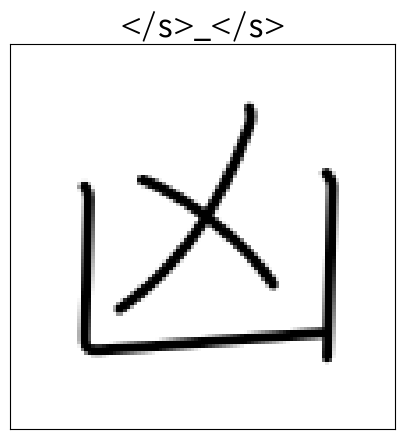

庵   </s>魔</s>   tensor([[2]])


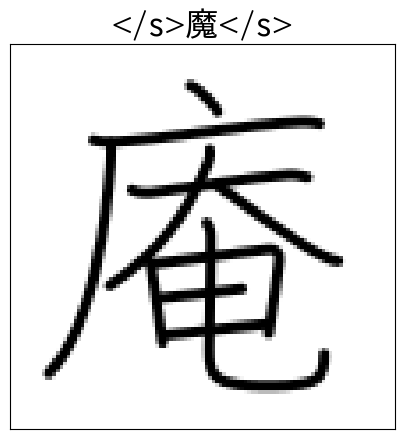

相   </s>自</s>   tensor([[2]])


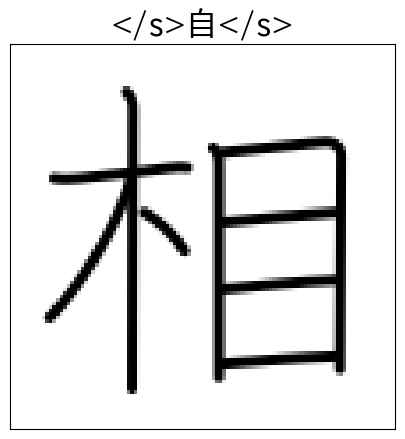

蜀   </s>撮」</s>   tensor([[2]])


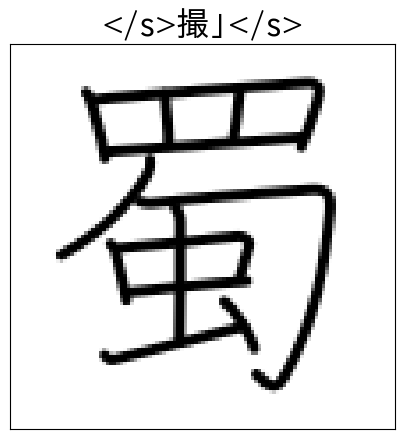

顎   </s>写真</s>   tensor([[2]])


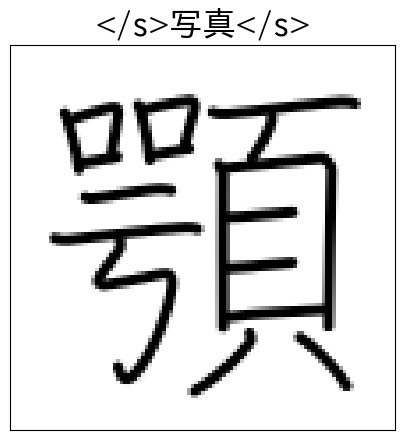

狸   </s>ろ里</s>   tensor([[2]])


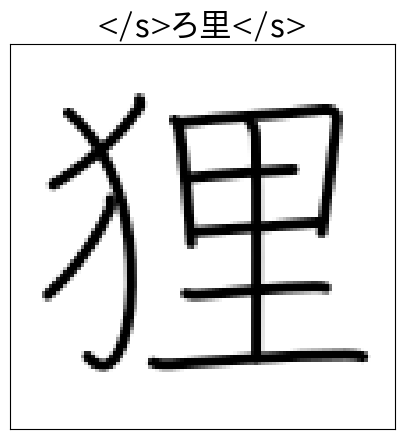

珍   </s>珍</s>   tensor([[2]])


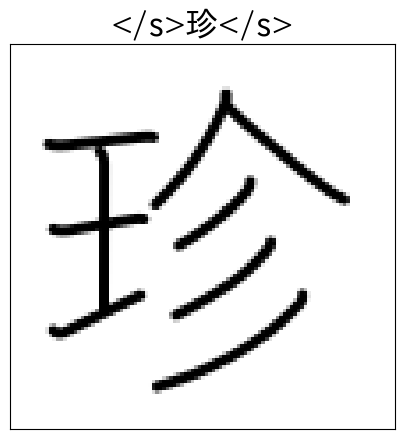

剣   </s>剣</s>   tensor([[2]])


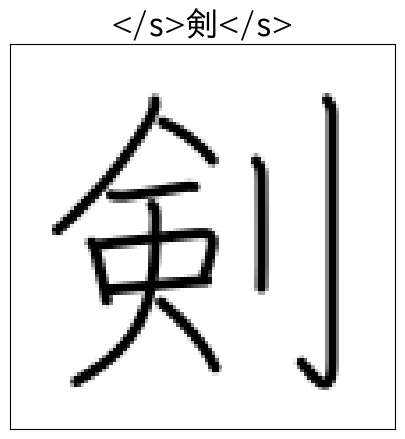

x   </s></s>   tensor([[2]])


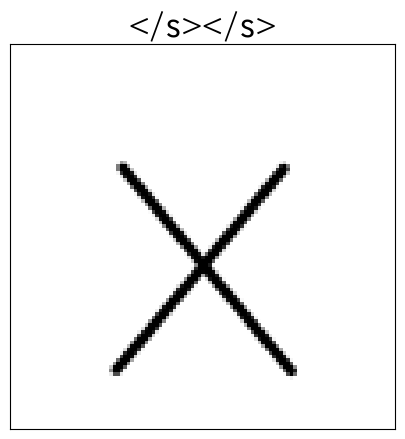

来   </s>来</s>   tensor([[2]])


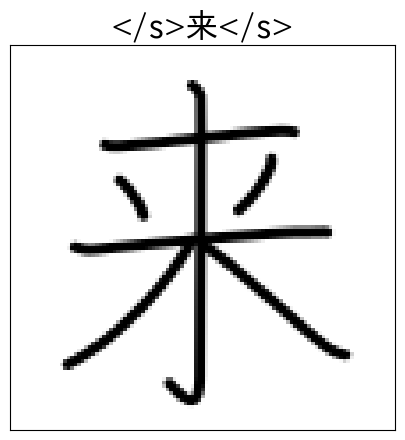

In [9]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

print(train_word_records[DATASET_TO_CHECK[0]][0])

for test_word_record in train_word_records[DATASET_TO_CHECK[0]][:10]:
    image_file = test_word_record.file_path
    image = Image.open(image_file).convert('RGB')
    
    inputs = test_processor(
        images=image, 
        texts='',
        return_tensors='pt'
    )
    
    model_output = model.generate(
        inputs, 
        test_processor,
        num_beams=1
    )
    
    predicted_text = test_processor.tokeniser.decode(model_output[0], skip_special_tokens=False)
    
    print(test_word_record.transcription, ' ', predicted_text, ' ', inputs.input_ids)
    plt.figure(figsize=(10, 5))
    plt.title(predicted_text, fontsize=24)
    plt.imshow(np.array(image, dtype=np.uint8))
    plt.xticks([]), plt.yticks([])
    plt.show()

In [10]:
tokeniser = test_processor.tokeniser
print(tokeniser.pad_token)
print(tokeniser.eos_token)
print(tokeniser.bos_token)
print(tokeniser.model_max_length)
print(tokeniser.sep_token_id)

print(tokeniser('<s>[SEP]'))

[PAD]
</s>
<s>
128
5
{'input_ids': [1, 5, 2], 'attention_mask': [1, 1, 1]}
